---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 9. МДН-транзистори (MOSFET)</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>МДН-структура: збагачення, збіднення, інверсія; вольт-фарадна характеристика</li>
  <li>Порогова напруга і фактори, що її визначають</li>
  <li>МДН-транзистори з індукованим і вбудованим каналом, умовні позначення</li>
  <li>Статичні характеристики: тріодна область і насичення, модуляція довжини каналу</li>
  <li>Ефект підкладки і підпорогова область</li>
  <li>КМДН-інвертор — основа цифрової мікроелектроніки</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 9 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [МДН-структура](#mos-capacitor)
    * [🔬 Розрахунок: зонні діаграми та C–V характеристика МДН-конденсатора](#mos-cv)
* [Порогова напруга](#threshold)
* [Типи МДН-транзисторів](#mosfet-types)
* [Статичні характеристики МДН-транзистора](#mosfet-iv)
    * [⚙️ PySpice: характеристики 2N7000 і квадратичний закон](#spice-2n7000)
* [Ефект підкладки](#body-effect)
* [Підпорогова область](#subthreshold)
    * [⚙️ PySpice: ефект підкладки і підпороговий струм (модель BSIM3)](#spice-body-sub)
* [КМДН-інвертор](#cmos)
    * [⚙️ PySpice: передавальна характеристика і струм споживання](#spice-cmos)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

eps_s, eps_ox = 11.7*eps0*1e-2, 3.9*eps0*1e-2      # Ф/см
ni = 9.65e9
def mos_params(Na=1e17, tox_nm=10.0, T=300.0):
    Cox = eps_ox/(tox_nm*1e-7); phiF = phi_T(T)*np.log(Na/ni)
    VFB = -(0.56 + phiF)                              # n+ полікремнієвий затвор на p-підкладці, без заряду в оксиді
    VT = VFB + 2*phiF + np.sqrt(2*q*eps_s*Na*2*phiF)/Cox
    gamma = np.sqrt(2*q*eps_s*Na)/Cox
    return dict(Cox=Cox, phiF=phiF, VFB=VFB, VT=VT, gamma=gamma)
p = mos_params()
print(f"Na = 1e17 см^-3, tox = 10 нм:  Cox = {p['Cox']*1e9:.0f} нФ/см², φF = {p['phiF']:.3f} В, U_FB = {p['VFB']:.2f} В, U_пор = {p['VT']:.2f} В, γ = {p['gamma']:.2f} В^0,5")

Na = 1e17 см^-3, tox = 10 нм:  Cox = 345 нФ/см², φF = 0.418 В, U_FB = -0.98 В, U_пор = 0.34 В, γ = 0.53 В^0,5


---

# МДН-структура <a class="anchor" id="mos-capacitor"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати режими збагачення, збіднення та інверсії МДН-структури за зонними діаграмами
> - Розраховувати порогову напругу і пояснювати вплив легування, товщини оксиду і заряду в оксиді
> - Розрізняти МДН-транзистори з індукованим і вбудованим каналом, n- і p-типу
> - Використовувати квадратичну модель МДН-транзистора для тріодної області та насичення
> - Пояснювати ефект підкладки і підпорогову провідність
> - Пояснювати роботу КМДН-інвертора та його переваги

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **МДН (МОН, MOS)** | Структура метал (полікремній) – діелектрик (оксид $SiO_2$) – напівпровідник |
| **Інверсійний шар** | Тонкий шар біля поверхні з типом провідності, протилежним підкладці — провідний канал |
| **Порогова напруга $U_{пор}$ ($V_T$)** | Напруга на затворі, при якій поверхневий потенціал досягає $2\varphi_F$ (сильна інверсія) |
| **Питома ємність оксиду $C_{ox}$** | $C_{ox} = \varepsilon_{ox}/t_{ox}$ ≈ 3,45 мкФ/см² при $t_{ox}$ = 10 нм |
| **Ефект підкладки** | Зростання порогової напруги при зворотному зміщенні підкладка–витік |
| **КМДН (CMOS)** | Комплементарна пара n- і p-канальних МДН-транзисторів |

**МДН-конденсатор** — металевий (сучасні ІМС — полікремнієвий або металевий із заданою роботою виходу) затвор, ізольований від напівпровідникової підкладки тонким шаром діелектрика ($SiO_2$, у сучасних ІМС — $HfO_2$ з високою $\varepsilon$). Розглянемо p-підкладку ($N_a$). Залежно від напруги на затворі $U_З$ біля поверхні напівпровідника встановлюється один з режимів:

1. **Збагачення (акумуляція)**, $U_З < U_{FB}$ — від'ємний затвор притягує дірки (основні носії) до поверхні, зони згинаються **вгору**. Ємність структури дорівнює $C_{ox}$.
2. **Плоских зон**, $U_З = U_{FB}$ — напруга, що компенсує різницю робіт виходу затвора й підкладки ($\varphi_{мн}$) і заряд в оксиді; зони не зігнуті.
3. **Збіднення**, $U_{FB} < U_З < U_{пор}$ — додатний затвор відштовхує дірки; біля поверхні утворюється збіднений шар іонів акцепторів завтовшки $W_d = \sqrt{2\varepsilon\psi_s/qN_a}$; зони згинаються **вниз** на поверхневий потенціал $\psi_s$. Ємність спадає: $C = C_{ox}C_d/(C_{ox} + C_d)$.
4. **Інверсія**, $U_З > U_{пор}$ — поверхневий потенціал досягає $2\varphi_F$, де $\varphi_F = \varphi_T\ln(N_a/n_i)$. Біля поверхні концентрація **електронів** (неосновних носіїв) перевищує концентрацію дірок в об'ємі — утворюється **інверсійний n-шар**. Подальше зростання $U_З$ збільшує заряд інверсійного шару, а збіднений шар майже не розширюється ($W_{d.max}$).

Саме інверсійний шар стає **каналом** МДН-транзистора: він з'єднує $n^+$ витік і стік.

### 🔬 Розрахунок: зонні діаграми та C–V характеристика МДН-конденсатора <a class="anchor" id="mos-cv"></a>

Зонні діаграми розраховано в наближенні повного збіднення для p-Si ($N_a = 10^{17}$ см⁻³, $t_{ox}$ = 10 нм). Вольт-фарадну характеристику (C–V) розраховано за повним виразом для заряду напівпровідника $Q_s(\psi_s)$. На **низькій** частоті інверсійний заряд встигає змінюватися разом із сигналом, і ємність повертається до $C_{ox}$. На **високій** частоті (1 МГц) — не встигає, і ємність залишається мінімальною. Саме так технологи контролюють якість оксиду і легування.

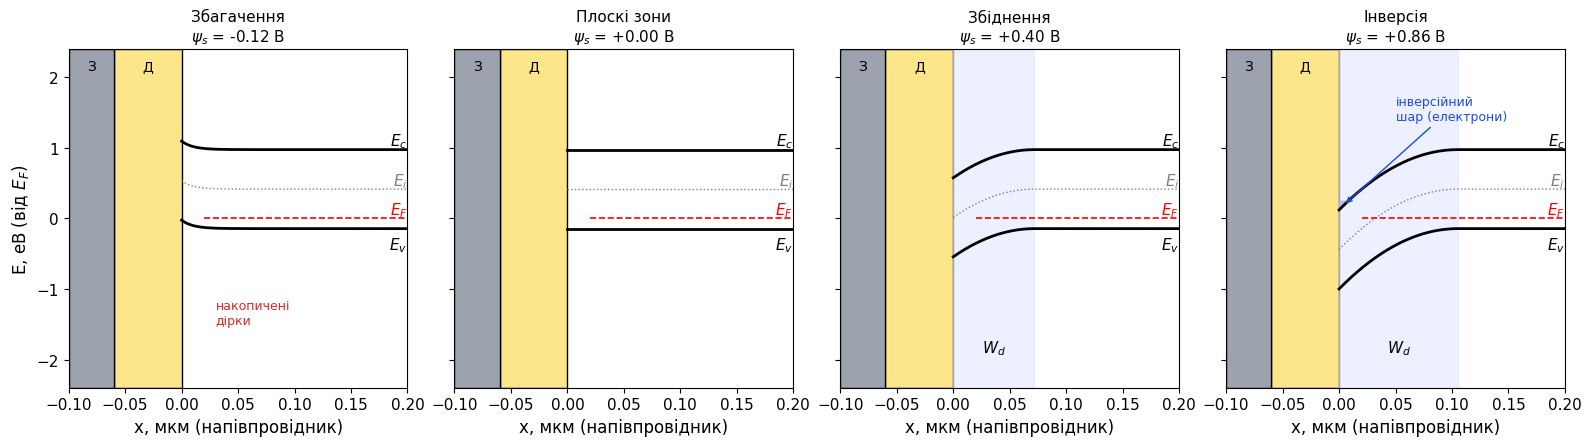

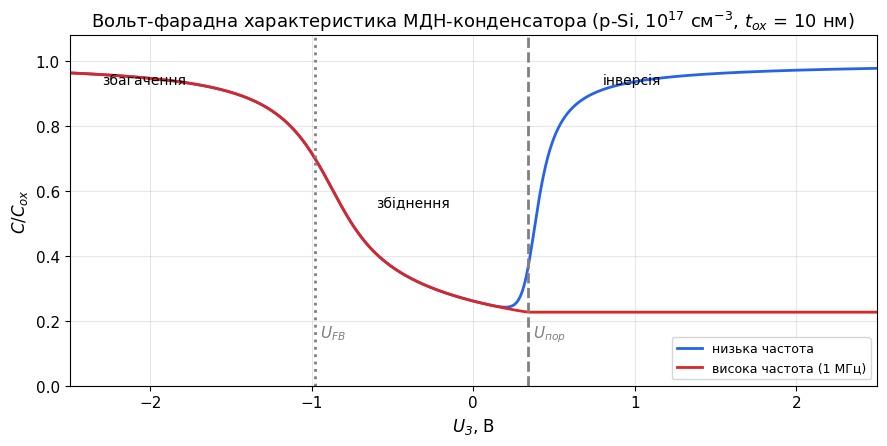

In [2]:
Na, tox_nm = 1e17, 10.0
p = mos_params(Na, tox_nm); pT = phi_T(); Eg = 1.12
fig, axes = plt.subplots(1, 4, figsize=(16, 4.6), sharey=True)
modes = [(-0.12, 'Збагачення'), (0.0, 'Плоскі зони'), (0.4, 'Збіднення'), (2*p['phiF'] + 0.02, 'Інверсія')]
EcEF_bulk = Eg - pT*np.log(2.66e19/Na)      # Ec − EF в об'ємі p-Si
for ax, (psi_s, ttl) in zip(axes, modes):
    x = np.linspace(0, 0.2, 400)                                      # мкм від межі Si/SiO2
    if psi_s > 0:
        Wd = np.sqrt(2*eps_s*psi_s/(q*Na))*1e4
        psi = np.where(x < Wd, psi_s*(1 - x/Wd)**2, 0.0)
    else:
        psi = psi_s*np.exp(-x/0.01)                                   # акумуляція: тонкий шар (довжина Дебая)
    Ec = EcEF_bulk - psi; Ev = Ec - Eg; Ei = Ec - Eg/2
    ax.add_patch(patches.Rectangle((-0.06, -2.4), 0.06, 4.8, fc='#fde68a', ec='k'))            # оксид
    ax.add_patch(patches.Rectangle((-0.1, -2.4), 0.04, 4.8, fc='#9ca3af', ec='k'))             # затвор
    ax.plot(x, Ec, 'k', lw=2); ax.plot(x, Ev, 'k', lw=2); ax.plot(x, Ei, ':', color='gray', lw=1)
    ax.axhline(0, xmin=0.4, color='r', ls='--', lw=1.2)
    ax.text(0.2, 0.06, '$E_F$', color='r', ha='right'); ax.text(0.2, Ec[-1] + 0.06, '$E_c$', ha='right'); ax.text(0.2, Ev[-1] - 0.3, '$E_v$', ha='right')
    ax.text(0.2, Ei[-1] + 0.05, '$E_i$', ha='right', color='gray')
    if psi_s > 0.5:
        ax.fill_between(x, Ec, np.where(Ec < 0.25, 0.25, Ec), where=Ec < 0.25, color='#2563eb', alpha=0.7)
        ax.annotate('інверсійний\nшар (електрони)', xy=(0.004, Ec[2] + 0.05), xytext=(0.05, 1.4), fontsize=9, color='#1d4ed8',
                    arrowprops=dict(arrowstyle='->', color='#1d4ed8'))
    if psi_s > 0:
        ax.axvspan(0, Wd, color='#e0e7ff', alpha=0.6); ax.text(Wd/2, -1.9, '$W_d$', ha='center')
    if psi_s < 0: ax.text(0.03, -1.5, 'накопичені\nдірки', fontsize=9, color='#dc2626')
    ax.text(-0.08, 2.1, 'З', ha='center', fontsize=10); ax.text(-0.03, 2.1, 'Д', ha='center', fontsize=10)
    ax.set_xlim(-0.1, 0.2); ax.set_ylim(-2.4, 2.4); ax.set_title(f'{ttl}\n$\\psi_s$ = {psi_s:+.2f} В', fontsize=11)
    ax.set_xlabel('x, мкм (напівпровідник)'); ax.grid(False)
axes[0].set_ylabel('E, еВ (від $E_F$)')
plt.tight_layout(); plt.show()

# C–V характеристика (повна модель заряду напівпровідника)
psi = np.linspace(-0.3, 1.2, 3000)
pp0, np0 = Na, ni**2/Na
F = np.sqrt(np.clip((np.exp(-psi/pT) + psi/pT - 1) + np0/pp0*(np.exp(psi/pT) - psi/pT - 1), 1e-30, None))
LD = np.sqrt(eps_s*pT/(q*pp0))
Qs = -np.sign(psi)*np.sqrt(2)*eps_s*pT/LD*F
Ug = p['VFB'] + psi - Qs/p['Cox']
Cs_lf = np.abs(np.gradient(Qs, psi))
C_lf = 1/(1/p['Cox'] + 1/Cs_lf)
# ВЧ: інверсійний заряд не встигає за сигналом → враховуємо лише основні носії + збіднення; вище 2φF ємність «заморожена»
Fmaj = np.sqrt(np.clip(np.exp(-psi/pT) + psi/pT - 1, 1e-30, None))
Qmaj = -np.sign(psi)*np.sqrt(2)*eps_s*pT/LD*Fmaj
Cs_hf = np.abs(np.gradient(Qmaj, psi))
Cs_hf = np.where(psi > 2*p['phiF'], np.interp(2*p['phiF'], psi, Cs_hf), Cs_hf)
C_hf = 1/(1/p['Cox'] + 1/Cs_hf)
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(Ug, C_lf/p['Cox'], color='#2563eb', lw=2, label='низька частота')
ax.plot(Ug, C_hf/p['Cox'], color='#dc2626', lw=2, label='висока частота (1 МГц)')
ax.axvline(p['VFB'], color='gray', ls=':'); ax.text(p['VFB'] + 0.03, 0.15, '$U_{FB}$', color='gray')
ax.axvline(p['VT'], color='gray', ls='--'); ax.text(p['VT'] + 0.03, 0.15, '$U_{пор}$', color='gray')
ax.text(-2.3, 0.93, 'збагачення', fontsize=10); ax.text(-0.6, 0.55, 'збіднення', fontsize=10); ax.text(0.8, 0.93, 'інверсія', fontsize=10)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(0, 1.08); ax.set_xlabel('$U_З$, В'); ax.set_ylabel('$C/C_{ox}$'); ax.legend(fontsize=9, loc='lower right')
ax.set_title('Вольт-фарадна характеристика МДН-конденсатора (p-Si, $10^{17}$ см$^{-3}$, $t_{ox}$ = 10 нм)')
plt.tight_layout(); plt.show()

---

# Порогова напруга <a class="anchor" id="threshold"></a>

Порогова напруга — сума напруги плоских зон, напруги на напівпровіднику ($2\varphi_F$) і напруги на оксиді, потрібної для утримання заряду збідненого шару:

$$U_{пор} = U_{FB} + 2\varphi_F + \frac{\sqrt{2q\varepsilon_s N_a\,2\varphi_F}}{C_{ox}}, \qquad U_{FB} = \varphi_{мн} - \frac{Q_{ox}}{C_{ox}}.$$

$U_{пор}$ зростає з легуванням підкладки і товщиною оксиду; фіксований позитивний заряд в оксиді $Q_{ox}$ і матеріал затвора ($\varphi_{мн}$) зсувають її. Технологи підганяють поріг **імплантацією** невеликої дози домішки в канал. Для сучасних логічних транзисторів $U_{пор}$ = 0,2–0,5 В, для потужних МДН — 2–4 В (щоб завади не відкривали ключ).

In [3]:
def threshold(lgNa=17.0, tox_nm=10.0, Qox_1e11=0.0):
    Na = 10**lgNa; pr = mos_params(Na, tox_nm)
    VT = pr['VT'] - Qox_1e11*1e11*q/pr['Cox']
    parts = {'$U_{FB}$ (різниця робіт виходу)': pr['VFB'], '$2\\varphi_F$': 2*pr['phiF'],
             '$Q_d/C_{ox}$ (заряд збідн. шару)': pr['VT'] - pr['VFB'] - 2*pr['phiF'], '$-Q_{ox}/C_{ox}$': -Qox_1e11*1e11*q/pr['Cox']}
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    cols = ['#7c3aed', '#2563eb', '#16a34a', '#dc2626']
    axes[0].barh(list(parts.keys()), list(parts.values()), color=cols); axes[0].axvline(0, color='k', lw=0.8)
    axes[0].set_xlabel('В'); axes[0].set_title(f'Складові порогової напруги: $U_{{пор}}$ = {VT:.2f} В')
    Ns = np.logspace(15, 18.5, 100)
    for t, col in [(2, '#f59e0b'), (5, '#16a34a'), (10, '#2563eb'), (50, '#7c3aed')]:
        axes[1].semilogx(Ns, [mos_params(n, t)['VT'] - Qox_1e11*1e11*q/mos_params(n, t)['Cox'] for n in Ns], color=col, label=f'$t_{{ox}}$ = {t} нм')
    axes[1].plot(Na, VT, 'ko'); axes[1].axhline(0, color='k', lw=0.6)
    axes[1].set_xlabel('$N_a$, см$^{-3}$'); axes[1].set_ylabel('$U_{пор}$, В'); axes[1].set_title('Порогова напруга n-канального МДН-транзистора'); axes[1].legend(fontsize=9)
    axes[1].set_ylim(-1.5, 6)
    plt.tight_layout(); plt.show()

interact(threshold, lgNa=widgets.FloatSlider(min=15, max=18.5, step=0.1, value=17, description='lg $N_a$', continuous_update=False),
         tox_nm=widgets.FloatLogSlider(value=10, base=10, min=0.3, max=2, step=0.05, description='$t_{ox}$, нм', continuous_update=False),
         Qox_1e11=widgets.FloatSlider(min=0, max=10, step=0.5, value=0, description='$Q_{ox}/q$, $10^{11}$ см$^{-2}$',
                                      style={'description_width': 'initial'}, continuous_update=False));

interactive(children=(FloatSlider(value=17.0, continuous_update=False, description='lg $N_a$', max=18.5, min=1…

---

# Типи МДН-транзисторів <a class="anchor" id="mosfet-types"></a>

**МДН-транзистор з індукованим каналом** (enhancement mode, «нормально закритий»): на p-підкладці сформовано $n^+$ витік і стік; при $U_{ЗВ} = 0$ між ними два зустрічно ввімкнені p-n переходи — струму немає. Канал **індукується** полем затвора лише при $U_{ЗВ} > U_{пор}$. На умовному позначенні лінія каналу **переривчаста** (три відрізки).

**МДН-транзистор зі вбудованим каналом** (depletion mode, «нормально відкритий»): тонкий n-шар каналу створено технологічно (імплантацією), тому струм тече вже при $U_{ЗВ} = 0$. Від'ємна напруга затвора збіднює канал (до відсічки при $U_{ЗВ} = U_{ЗВ.відс} < 0$), додатна — збагачує. На позначенні лінія каналу **суцільна**.

Кожен тип буває з **n-** і **p-каналом** (стрілка підкладки спрямована до каналу для n-типу і від каналу — для p-типу). Підкладку (П, B) зазвичай з'єднують з витоком. У дискретних і потужних транзисторах через це утворюється **паразитний діод** витік–стік (body diode), який проводить у зворотному напрямку.

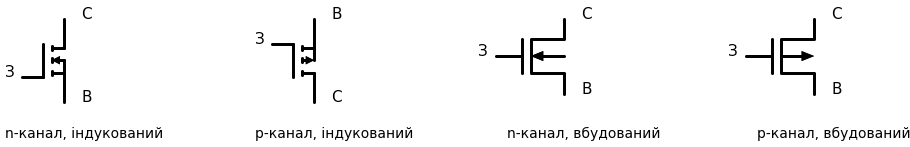

In [4]:
if SCHEMDRAW_AVAILABLE:
    class DepletionMos(elm.NFet):
        """МДН зі вбудованим каналом (суцільна лінія каналу); для p-каналу стрілка підкладки — від каналу."""
        _element_defaults = {**elm.NFet._element_defaults, 'bulk': True}   # вивід підкладки зі стрілкою
        def __init__(self, pchannel=False, **kw):
            super().__init__(**kw)
            if pchannel:
                for seg in self.segments:
                    if getattr(seg, 'arrow', None): seg.path = list(seg.path)[::-1]
    with schemdraw.Drawing(fontsize=11, unit=2) as d:
        items = [(elm.NMos(), 'n-канал, індукований'), (elm.PMos(), 'p-канал, індукований'),
                 (DepletionMos().reverse(), 'n-канал, вбудований'), (DepletionMos(pchannel=True).reverse(), 'p-канал, вбудований')]
        for k, (E, name) in enumerate(items):
            t = d.add(E.at((k*5.0, 0)).theta(0))
            for a_, lab in [('gate', 'З'), ('drain', 'С'), ('source', 'В')]:
                xa, ya = t.absanchors[a_]
                d.add(elm.Label().at((xa + (-0.35 if a_ == 'gate' else 0.35), ya)).label(lab))
            d.add(elm.Label().at((k*5.0 + 0.3, -2.4)).label(name, fontsize=10))

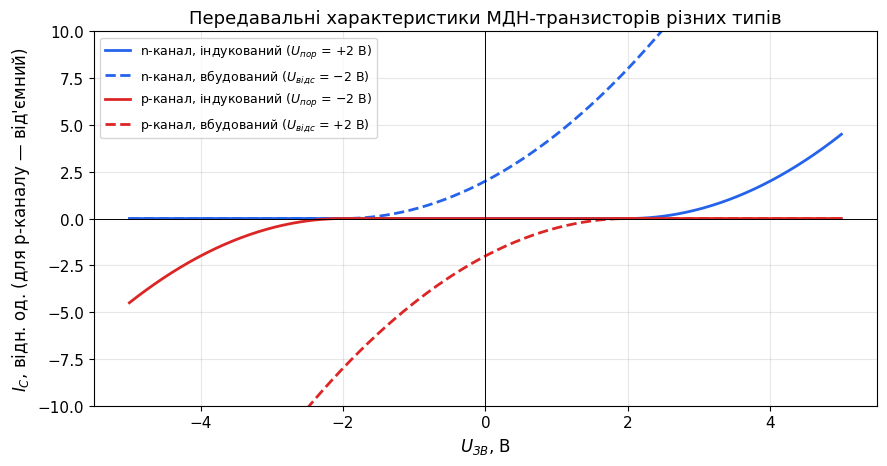

In [5]:
# Передавальні характеристики чотирьох типів МДН-транзисторів (насичення, квадратичний закон)
fig, ax = plt.subplots(figsize=(9, 4.8))
U = np.linspace(-5, 5, 500); k = 1.0
for Vt, sgn, lab, col, ls in [(2.0, 1, 'n-канал, індукований ($U_{пор}$ = +2 В)', '#2563eb', '-'), (-2.0, 1, 'n-канал, вбудований ($U_{відс}$ = −2 В)', '#2563eb', '--'),
                              (-2.0, -1, 'p-канал, індукований ($U_{пор}$ = −2 В)', '#dc2626', '-'), (2.0, -1, 'p-канал, вбудований ($U_{відс}$ = +2 В)', '#dc2626', '--')]:
    ov = sgn*(U - Vt); I = sgn*k/2*np.clip(ov, 0, None)**2
    ax.plot(U, I, color=col, ls=ls, lw=2, label=lab)
ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
ax.set_xlabel('$U_{ЗВ}$, В'); ax.set_ylabel('$I_С$, відн. од. (для p-каналу — від\'ємний)'); ax.set_ylim(-10, 10)
ax.set_title('Передавальні характеристики МДН-транзисторів різних типів'); ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

---

# Статичні характеристики МДН-транзистора <a class="anchor" id="mosfet-iv"></a>

Заряд інверсійного шару на одиницю площі $Q_n = -C_{ox}(U_{ЗВ} - U_{пор} - V(x))$ залежить від потенціалу каналу $V(x)$, який зростає від витоку до стоку. Інтегрування дрейфового струму вздовж каналу (наближення плавного каналу) дає **квадратичну модель** (модель Шихмана–Ходжеса, SPICE level 1):

$$\text{тріодна область}\;(U_{СВ} < U_{ЗВ} - U_{пор}): \quad I_С = k'\frac{W}{L}\left[(U_{ЗВ} - U_{пор})U_{СВ} - \frac{U_{СВ}^2}{2}\right],$$

$$\text{насичення}\;(U_{СВ} \ge U_{ЗВ} - U_{пор}): \quad I_С = \frac{k'}{2}\frac{W}{L}(U_{ЗВ} - U_{пор})^2(1 + \lambda U_{СВ}),$$

де $k' = \mu_nC_{ox}$ — питома крутизна технологічного процесу (параметр `KP`), $W/L$ — відношення ширини до довжини каналу. У насиченні канал **перекривається біля стоку** (інверсійний заряд там дорівнює нулю). Невеликий нахил пологої ділянки — **модуляція довжини каналу** (параметр `λ`, аналог ефекту Ерлі).

**Крутизна** в насиченні $g_m = k'\frac{W}{L}(U_{ЗВ} - U_{пор}) = \sqrt{2k'\frac{W}{L}I_С} = \frac{2I_С}{U_{ЗВ} - U_{пор}}$. При малих $U_{СВ}$ канал — резистор $R_{on} = 1/[k'\frac{W}{L}(U_{ЗВ} - U_{пор})]$ — це опір відкритого ключа ($R_{DS(on)}$).

У сучасних транзисторах з коротким каналом через **насичення швидкості** носіїв залежність стає ближчою до лінійної: $I_С \propto (U_{ЗВ} - U_{пор})^\alpha$, $\alpha$ ≈ 1,2–1,5.

### ⚙️ PySpice: характеристики 2N7000 і квадратичний закон <a class="anchor" id="spice-2n7000"></a>

2N7000 — дискретний n-канальний МДН-транзистор з індукованим каналом (модель Zetex, level 1: $U_{пор}$ = 2,47 В, $K_P$ = 0,296 А/В², $R_S$ = 1,68 Ом). Пунктиром — розрахунок за квадратичною моделлю для внутрішнього транзистора.

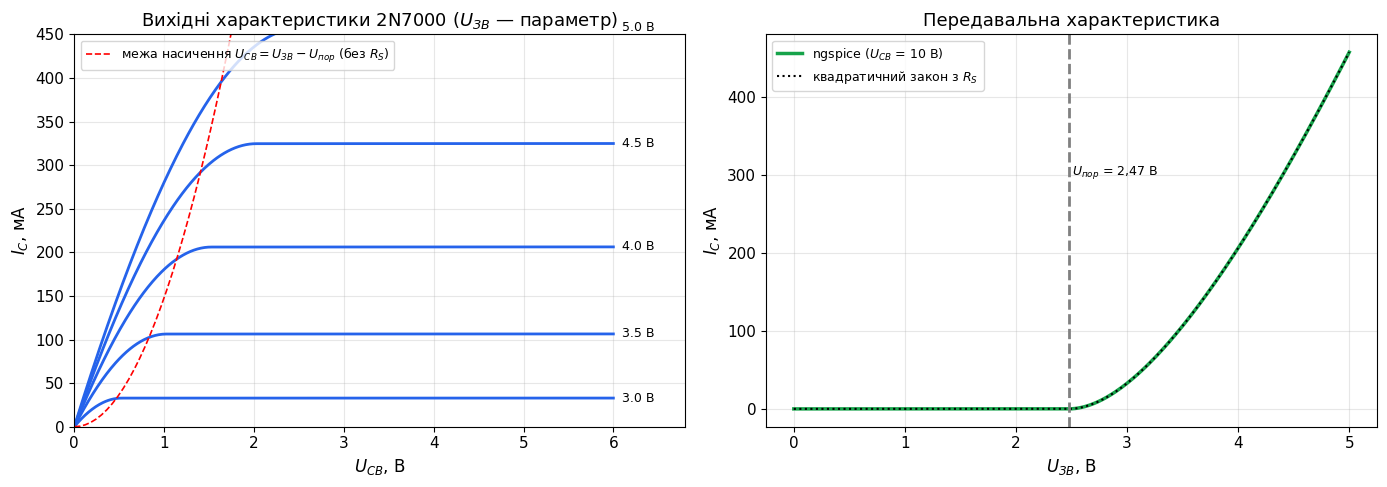

Опір відкритого каналу R_DS(on) при U_ЗВ = 10 В: 2.13 Ом (паспорт: 1,2–5 Ом)


In [6]:
c = Circuit('2N7000'); c.include(lib('mosfet'))
c.V('gs', 'g', c.gnd, 0); c.V('ds', 'd', c.gnd, 0); c.X('1', '2N7000_ZX', 'd', 'g', c.gnd)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for Ugs in [3.0, 3.5, 4.0, 4.5, 5.0]:
    c['Vgs'].dc_value = Ugs
    an = c.simulator().dc(Vds=slice(0, 6, 0.01))
    U, I = np.array(an.sweep), -np.array(an.branches['vds'])
    axes[0].plot(U, I*1e3, color='#2563eb', lw=2); axes[0].text(6.1, I[-1]*1e3, f'{Ugs} В', va='center', fontsize=9)
u = np.linspace(0, 6, 100); axes[0].plot(u, 0.296/2*u**2*1e3, 'r--', lw=1.2, label='межа насичення $U_{СВ} = U_{ЗВ} - U_{пор}$ (без $R_S$)')
axes[0].set_xlim(0, 6.8); axes[0].set_ylim(0, 450); axes[0].set_xlabel('$U_{СВ}$, В'); axes[0].set_ylabel('$I_С$, мА')
axes[0].set_title('Вихідні характеристики 2N7000 ($U_{ЗВ}$ — параметр)'); axes[0].legend(fontsize=9, loc='upper left')
c['Vds'].dc_value = 10
an = c.simulator().dc(Vgs=slice(0, 5, 0.01)); Ug, Id = np.array(an.sweep), -np.array(an.branches['vds'])
axes[1].plot(Ug, Id*1e3, color='#16a34a', lw=2.5, label='ngspice ($U_{СВ}$ = 10 В)')
from scipy.optimize import brentq
Iq = [brentq(lambda I: I - 0.296/2*max(u - I*1.68 - 2.474, 0)**2*(1 + 267e-6*10), 0, 5) if u > 2.474 else 0 for u in Ug]
axes[1].plot(Ug, np.array(Iq)*1e3, 'k:', lw=1.5, label='квадратичний закон з $R_S$')
axes[1].axvline(2.474, color='gray', ls='--'); axes[1].text(2.5, 300, '$U_{пор}$ = 2,47 В', fontsize=9)
axes[1].set_xlabel('$U_{ЗВ}$, В'); axes[1].set_ylabel('$I_С$, мА'); axes[1].set_title('Передавальна характеристика'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
c2 = Circuit('Ron'); c2.include(lib('mosfet')); c2.V('gs', 'g', c2.gnd, 10); c2.V('ds', 'd', c2.gnd, 0.1); c2.X('1', '2N7000_ZX', 'd', 'g', c2.gnd)
Ron = 0.1/(-float(c2.simulator().operating_point().branches['vds'][0]))
print(f'Опір відкритого каналу R_DS(on) при U_ЗВ = 10 В: {Ron:.2f} Ом (паспорт: 1,2–5 Ом)')

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Насичення МДН-транзистора ≠ насичення біполярного.** У МДН-транзисторі «насиченням» називають пологу ділянку, де струм стоку майже сталий — вона відповідає **активному** режиму БТ, і саме там працюють підсилювачі. А ключ на МДН-транзисторі у ввімкненому стані працює в **тріодній (омічній)** області з малим $U_{СВ} = I_СR_{DS(on)}$. Вона відповідає **насиченню** БТ. В англомовній літературі тріодну область іноді називають linear region, тому стежте за контекстом.

</div>

---

# Ефект підкладки <a class="anchor" id="body-effect"></a>

Якщо підкладка зміщена відносно витоку у зворотному напрямку ($U_{ПВ} < 0$ для n-каналу, $U_{ВП} > 0$), збіднений шар під каналом розширюється, його заряд зростає, і для утворення каналу потрібна більша напруга затвора:

$$U_{пор}(U_{ВП}) = U_{пор0} + \gamma\left(\sqrt{2\varphi_F + U_{ВП}} - \sqrt{2\varphi_F}\right), \qquad \gamma = \frac{\sqrt{2q\varepsilon_sN_a}}{C_{ox}}.$$

Коефіцієнт $\gamma$ (0,3–1 В$^{0,5}$) — параметр `GAMMA` моделі. Ефект важливий в інтегральних схемах, де багато транзисторів мають спільну підкладку, а їхні витоки під різними потенціалами (наприклад, верхні транзистори в «стовпчику»). Підкладку можна використовувати як **другий затвор** («back gate»).

# Підпорогова область <a class="anchor" id="subthreshold"></a>

Нижче порога струм не дорівнює нулю: канал у режимі **слабкої інверсії** проводить дифузійний струм, який експоненційно залежить від напруги затвора (як струм колектора БТ від $U_{БЕ}$):

$$I_С \approx I_0\,e^{(U_{ЗВ} - U_{пор})/n\varphi_T}\left(1 - e^{-U_{СВ}/\varphi_T}\right), \qquad S = n\varphi_T\ln10 = 60n\ \text{мВ/декаду},$$

де $n = 1 + C_d/C_{ox}$ ≈ 1,2–1,6. **Підпороговий нахил** $S$ не може бути меншим за 60 мВ/дек при 300 К — це фундаментальне обмеження для зменшення напруги живлення: щоб струм закритого транзистора був у $10^5$ разів менший за струм відкритого, потрібно $U_{пор} \gtrsim 5S$ ≈ 0,4 В. Підпороговий струм — головне джерело **статичного споживання** сучасних мікропроцесорів (витоки мільярдів транзисторів). У мікропотужних аналогових схемах (годинники, медичні імпланти) транзистори працюють саме в підпороговому режимі.

### ⚙️ PySpice: ефект підкладки і підпороговий струм (модель BSIM3) <a class="anchor" id="spice-body-sub"></a>

Використано модель ngspice **BSIM3** (level 8) з параметрами за замовчуванням ($t_{ox}$ = 10 нм, $W/L$ = 10 мкм / 1 мкм) — вона, на відміну від level 1, описує підпорогову область. Логарифмічний масштаб струму показує експоненційну ділянку; лінійний — квадратичну.

In [7]:
def body_sub(Usb_max=3.0, log_scale=True):
    c = Circuit('BSIM3 body'); c.model('NB', 'NMOS', LEVEL=8, VERSION='3.3.0', TOX=10e-9)
    c.V('ds', 'd', c.gnd, 1.0); c.V('gs', 'g', c.gnd, 0); c.V('bs', 'b', c.gnd, 0)
    c.MOSFET(1, 'd', 'g', c.gnd, 'b', model='NB', l=1e-6, w=10e-6)
    fig, ax = plt.subplots(figsize=(9, 5))
    Vt_list = []
    for Usb, col in zip(np.linspace(0, Usb_max, 4), ['#2563eb', '#16a34a', '#f59e0b', '#dc2626']):
        c['Vbs'].dc_value = -Usb
        sim = c.simulator(); sim.options(gmin=1e-20)
        an = sim.dc(Vgs=slice(0, 3, 0.005)); Ug, Id = np.array(an.sweep), -np.array(an.branches['vds'])
        Vt = Ug[np.argmax(Id > 1e-6)]; Vt_list.append(Vt)
        if Usb == 0: Ug0, Id0 = Ug, Id
        (ax.semilogy if log_scale else ax.plot)(Ug, Id if log_scale else Id*1e3, color=col, lw=2, label=f'$U_{{ВП}}$ = {Usb:.1f} В')
    if log_scale:
        m = (Id0 > 1e-11) & (Id0 < 1e-8)
        S = np.polyfit(np.log10(Id0[m]), Ug0[m], 1)[0]*1e3
        ax.set_ylim(1e-13, 1e-2); ax.set_ylabel('$I_С$, А'); ax.grid(True, which='both', alpha=0.3)
        ax.text(0.1, 1e-5, f'підпороговий нахил\nS ≈ {S:.0f} мВ/декаду', fontsize=10)
    else:
        ax.set_ylabel('$I_С$, мА')
    ax.set_xlabel('$U_{ЗВ}$, В'); ax.set_title('Передавальні характеристики n-МДН (BSIM3, $U_{СВ}$ = 1 В)'); ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout(); plt.show()
    print('Порогова напруга (за струмом 1 мкА): ' + ',  '.join(f'U_ВП = {u:.1f} В → {v:.2f} В' for u, v in zip(np.linspace(0, Usb_max, 4), Vt_list)))

interact(body_sub, Usb_max=widgets.FloatSlider(min=1, max=5, step=0.5, value=3, description='max $U_{ВП}$, В', continuous_update=False),
         log_scale=widgets.Checkbox(value=True, description='логарифмічний масштаб'));

interactive(children=(FloatSlider(value=3.0, continuous_update=False, description='max $U_{ВП}$, В', max=5.0, …

---
### ✅ Питання для самоперевірки: МДН-структура і транзистор

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому інверсійний шар утворюється лише при $\psi_s \ge 2\varphi_F$?</summary>

> **Відповідь:** При $\psi_s = \varphi_F$ поверхня стає власною ($n = p = n_i$); при $\psi_s = 2\varphi_F$ концентрація електронів біля поверхні дорівнює концентрації дірок в об'ємі ($N_a$) — це умовний критерій сильної інверсії, після якого заряд електронів швидко (експоненційно) зростає.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому високочастотна C–V характеристика в інверсії не повертається до $C_{ox}$?</summary>

> **Відповідь:** Інверсійний заряд (неосновні носії) генерується термічно з часом від мс до с і не встигає змінюватися з частотою 1 МГц. Малий сигнал модулює лише край збідненого шару максимальної товщини — ємність $C_{ox}\|C_{d.min}$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як зміниться струм МДН-транзистора в насиченні, якщо відношення $W/L$ збільшити вдвічі?</summary>

> **Відповідь:** Удвічі — $I_С \propto W/L$. Саме ширину каналу $W$ конструктори ІМС вибирають, щоб задати струм і крутизну транзистора.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Чому підпороговий нахил не може бути меншим за 60 мВ/декаду?</summary>

> **Відповідь:** Струм у слабкій інверсії — це носії, що долають бар'єр за розподілом Больцмана, $\propto e^{\psi_s/\varphi_T}$; навіть при ідеальному зв'язку затвора з поверхнею ($n = 1$) десятикратна зміна струму потребує $\varphi_T\ln10$ = 59,5 мВ при 300 К.

</details>

---

# КМДН-інвертор <a class="anchor" id="cmos"></a>

**КМДН (CMOS) інвертор** — p-канальний транзистор між живленням і виходом та n-канальний між виходом і землею, затвори з'єднані (вхід):

- $U_{вх}$ = 0 → n-МДН закритий, p-МДН відкритий: $U_{вих} = U_{DD}$;
- $U_{вх} = U_{DD}$ → n-МДН відкритий, p-МДН закритий: $U_{вих}$ = 0.

У **статичних** станах один з транзисторів завжди закритий, тож струм споживання — лише струм витоку (нА). Енергія витрачається переважно **під час перемикання** — на перезаряд ємності навантаження: $P_{дин} = \alpha C_нU_{DD}^2f$. Це й зробило КМДН основою всієї цифрової мікроелектроніки (мікропроцесори, пам'ять, ПЛІС).

Поріг перемикання $U_M$ (де $U_{вх} = U_{вих}$) задається співвідношенням крутизни транзисторів. Оскільки рухливість дірок приблизно в 2–3 рази менша, p-МДН роблять ширшим ($W_p ≈ 2$–$3W_n$), щоб $U_M \approx U_{DD}/2$ і фронти були симетричні.

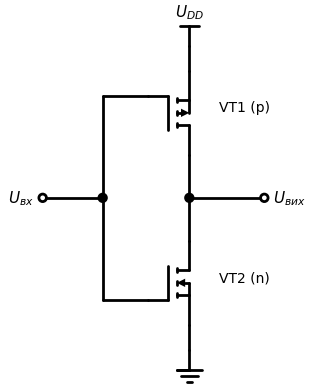

In [8]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2) as d:
        tp = d.add(elm.PMos().at((2, 3.4)).theta(0))                 # затвор ліворуч, витік угорі, стік унизу
        tn = d.add(elm.NMos().at((2, 0)).theta(0))                   # затвор ліворуч, стік угорі, витік унизу
        d.add(elm.Line().endpoints(tp.drain, tn.drain))
        d.add(elm.Line().endpoints(tp.source, (tp.source[0], tp.source[1] + 0.5))); d.add(elm.Vdd().at((tp.source[0], tp.source[1] + 0.5)).label('$U_{DD}$'))
        d.add(elm.Line().endpoints(tn.source, (tn.source[0], tn.source[1] - 0.5))); d.add(elm.Ground().at((tn.source[0], tn.source[1] - 0.5)))
        xg = tp.gate[0] - 0.9
        d.add(elm.Line().endpoints(tp.gate, (xg, tp.gate[1]))); d.add(elm.Line().endpoints(tn.gate, (xg, tn.gate[1])))
        d.add(elm.Line().endpoints((xg, tp.gate[1]), (xg, tn.gate[1])))
        ym = (tp.gate[1] + tn.gate[1])/2
        d.add(elm.Dot().at((xg, ym))); d.add(elm.Line().endpoints((xg, ym), (xg - 1.2, ym))); d.add(elm.Dot(open=True).at((xg - 1.2, ym)).label('$U_{вх}$', loc='left'))
        yo = (tp.drain[1] + tn.drain[1])/2
        d.add(elm.Dot().at((tp.drain[0], yo))); d.add(elm.Line().endpoints((tp.drain[0], yo), (tp.drain[0] + 1.5, yo)))
        d.add(elm.Dot(open=True).at((tp.drain[0] + 1.5, yo)).label('$U_{вих}$', loc='right'))
        d.add(elm.Label().at((tp.drain[0] + 1.0, tp.center[1])).label('VT1 (p)', fontsize=10))
        d.add(elm.Label().at((tn.drain[0] + 1.0, tn.center[1])).label('VT2 (n)', fontsize=10))

### ⚙️ PySpice: передавальна характеристика і струм споживання <a class="anchor" id="spice-cmos"></a>

Моделі BSIM3 (t$_{ox}$ = 10 нм, L = 1 мкм, $W_n$ = 2 мкм), ширину p-МДН задає повзунок.

In [9]:
def cmos(Udd=3.3, Wp_over_Wn=2.5):
    c = Circuit('CMOS inverter')
    c.model('NB', 'NMOS', LEVEL=8, VERSION='3.3.0', TOX=10e-9); c.model('PB', 'PMOS', LEVEL=8, VERSION='3.3.0', TOX=10e-9)
    c.V('dd', 'vdd', c.gnd, Udd); c.V('in', 'in', c.gnd, 0)
    c.MOSFET('p', 'out', 'in', 'vdd', 'vdd', model='PB', l=1e-6, w=2e-6*Wp_over_Wn)
    c.MOSFET('n', 'out', 'in', c.gnd, c.gnd, model='NB', l=1e-6, w=2e-6)
    sim = c.simulator(); sim.options(gmin=1e-20)
    an = sim.dc(Vin=slice(0, Udd, Udd/400))
    Uin, Uout = np.array(an.sweep), np.array(an['out']); Idd = -np.array(an.branches['vdd'])
    k = np.argmin(abs(Uout - Uin)); gain = -np.gradient(Uout, Uin).max()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    axes[0].plot(Uin, Uout, color='#7c3aed', lw=2.5); axes[0].plot([0, Udd], [0, Udd], ':', color='gray')
    axes[0].plot(Uin[k], Uout[k], 'ro'); axes[0].text(Uin[k] + 0.05, Uout[k] + 0.1, f'$U_M$ = {Uin[k]:.2f} В')
    axes[0].set_xlabel('$U_{вх}$, В'); axes[0].set_ylabel('$U_{вих}$, В'); axes[0].set_title(f'Передавальна характеристика, $U_{{DD}}$ = {Udd} В')
    axes[1].semilogy(Uin, np.clip(Idd, 1e-15, None), color='#dc2626', lw=2)
    axes[1].set_xlabel('$U_{вх}$, В'); axes[1].set_ylabel('$I_{DD}$, А'); axes[1].set_title('Струм споживання (наскрізний)'); axes[1].grid(True, which='both', alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'Поріг перемикання U_M = {Uin[k]:.2f} В (U_DD/2 = {Udd/2:.2f} В);  максимальне підсилення |dU_вих/dU_вх| = {gain:.0f}')
    print(f'Струм у статичних станах: {Idd[0]:.1e} А (вхід 0) і {Idd[-1]:.1e} А (вхід U_DD);  піковий наскрізний струм {Idd.max()*1e6:.0f} мкА')

interact(cmos, Udd=widgets.FloatSlider(min=1.2, max=5, step=0.1, value=3.3, description='$U_{DD}$, В', continuous_update=False),
         Wp_over_Wn=widgets.FloatSlider(min=0.5, max=5, step=0.25, value=2.5, description='$W_p/W_n$', continuous_update=False));

interactive(children=(FloatSlider(value=3.3, continuous_update=False, description='$U_{DD}$, В', max=5.0, min=…

---
### ⚡ Практичне застосування: Захист МДН-транзисторів від статичної електрики

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Оксид затвора завтовшки кілька нанометрів пробивається полем ~10 МВ/см, тобто вже при **одиницях–десятках вольт**. Статичний заряд тіла людини — тисячі вольт. Тому МДН-прилади (особливо дискретні без захисних діодів) зберігають у струмопровідній упаковці, а працюють з ними на антистатичному столі, із заземленим браслетом і паяльником. Входи КМДН-мікросхем захищені вбудованими діодами до шин живлення. Невикористані входи КМДН-мікросхем **не можна залишати «в повітрі»**: вони набирають заряд, транзистори напіввідкриваються, зростає наскрізний струм, мікросхема перегрівається.

</div>

---
### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Закон **Мура** (1965): кількість транзисторів на кристалі подвоюється приблизно кожні два роки. Від 2300 транзисторів у Intel 4004 (1971, технологія 10 мкм) до понад 100 мільярдів у сучасних процесорах (технологічні норми «3 нм»). Щоб зберегти керованість каналу при довжині в десятки атомних шарів, планарний МДН-транзистор замінили **FinFET** (канал-«плавник», охоплений затвором з трьох боків), а нині — **GAA** (gate-all-around, затвор охоплює канал-нанолист з усіх боків).

</div>

---
### ✅ Питання для самоперевірки: КМДН та практичні аспекти

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому КМДН-інвертор майже не споживає енергії в статичному стані?</summary>

> **Відповідь:** У будь-якому логічному стані один із двох послідовно ввімкнених транзисторів закритий, тож між $U_{DD}$ і землею немає провідного шляху — тече лише підпороговий струм витоку.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Від чого залежить динамічна потужність КМДН-схеми?</summary>

> **Відповідь:** $P = \alpha C_нU_{DD}^2f$ — від ємності навантаження, квадрата напруги живлення, частоти перемикань і коефіцієнта активності $\alpha$. Тому зниження $U_{DD}$ — найефективніший спосіб зменшити споживання.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Навіщо p-МДН в інверторі роблять ширшим за n-МДН?</summary>

> **Відповідь:** Рухливість дірок у 2–3 рази менша за рухливість електронів. Щоб крутизни транзисторів були однакові (симетричний поріг $U_M = U_{DD}/2$ і однакові фронти), ширину p-каналу збільшують у стільки ж разів.

</details>

---
### 📝 Задачі для самостійного розв'язання: МДН-транзистори


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Знайдіть питому ємність оксиду товщиною 10 нм ($\varepsilon_{ox} = 3{,}9$) і питому крутизну $k' = \mu_nC_{ox}$ при $\mu_n$ = 400 см²/(В·с).

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $C_{ox} = \varepsilon_{ox}\varepsilon_0/t_{ox} = 3{,}9\cdot8{,}85\cdot10^{-14}/10^{-6} = 0{,}345$ мкФ/см² (345 нФ/см²); $k' = 400\cdot3{,}45\cdot10^{-7} = 138$ мкА/В².

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** p-Si, $N_a = 10^{17}$ см⁻³, $t_{ox}$ = 10 нм, $n^+$ полікремнієвий затвор. Знайдіть $\varphi_F$ і порогову напругу.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\varphi_F = 0{,}02585\ln(10^{17}/9{,}65\cdot10^9) = 0{,}418$ В; $U_{FB} = -(0{,}56 + 0{,}418) = -0{,}98$ В; $Q_d/C_{ox} = \sqrt{2q\varepsilon_sN_a\cdot2\varphi_F}/C_{ox} = 0{,}48$ В; $U_{пор} = -0{,}98 + 0{,}84 + 0{,}48 \approx 0{,}34$ В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** n-МДН: $k'W/L$ = 2 мА/В², $U_{пор}$ = 1 В, λ = 0. Знайдіть струм і крутизну при $U_{ЗВ}$ = 3 В у насиченні, а також $R_{on}$ при малих $U_{СВ}$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $I_С = \frac{2}{2}(3 - 1)^2 = 4$ мА; $g_m = 2\cdot2 = 4$ мА/В; $R_{on} = 1/[2\cdot10^{-3}\cdot2] = 250$ Ом.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** γ = 0,53 В$^{0,5}$, $2\varphi_F$ = 0,84 В, $U_{пор0}$ = 0,34 В. Знайдіть порогову напругу при $U_{ВП}$ = 3 В.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U_{пор} = 0{,}34 + 0{,}53(\sqrt{3{,}84} - \sqrt{0{,}84}) = 0{,}34 + 0{,}53\cdot1{,}043 \approx 0{,}89$ В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 5.** КМДН-схема перемикає навантаження 10 пФ з частотою 100 МГц при $U_{DD}$ = 3,3 В (α = 1). Яка динамічна потужність? Якою вона стане при $U_{DD}$ = 1,8 В?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $P = CU^2f = 10^{-11}\cdot3{,}3^2\cdot10^8 = 10{,}9$ мВт; при 1,8 В — 3{,}2 мВт (у $(3{,}3/1{,}8)^2 \approx 3{,}4$ раза менше).

</details>

---

## 📌 Підсумок лекції 9: МДН-транзистори <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Величина | Формула | Типові значення |
|---|---|---|
| Порогова напруга | $U_{пор} = U_{FB} + 2\varphi_F + \sqrt{2q\varepsilon_sN_a2\varphi_F}/C_{ox}$ | 0,2–0,5 В (ІМС), 2–4 В (дискретні) |
| Тріодна область | $I_С = k'\frac{W}{L}[(U_{ЗВ}-U_{пор})U_{СВ} - U_{СВ}^2/2]$ | $R_{on}$ = мОм – кОм |
| Насичення | $I_С = \frac{k'}{2}\frac{W}{L}(U_{ЗВ}-U_{пор})^2(1+\lambda U_{СВ})$ | — |
| Крутизна | $g_m = 2I_С/(U_{ЗВ}-U_{пор})$ | мА/В – А/В |
| Ефект підкладки | $\Delta U_{пор} = \gamma(\sqrt{2\varphi_F + U_{ВП}} - \sqrt{2\varphi_F})$ | γ = 0,3–1 В$^{0,5}$ |
| Підпороговий нахил | $S = n\varphi_T\ln10$ | ≥ 60 мВ/дек |
| КМДН | $P_{дин} = \alpha C U_{DD}^2 f$ | статичний струм — нА |

**Головні висновки.** (1) Полем затвора через оксид можна перевести поверхню напівпровідника від збагачення до інверсії, а інверсійний шар — це канал МДН-транзистора. (2) Порогова напруга визначається легуванням, товщиною оксиду, матеріалом затвора і зарядом в оксиді. (3) Квадратична модель описує тріодну область і насичення; крутизна пропорційна $W/L$. (4) Ефект підкладки і підпорогова провідність — важливі «неідеальності» інтегральних МДН-транзисторів. (5) Комплементарна пара n- і p-МДН (КМДН) не споживає статичного струму — на ній побудована вся цифрова мікроелектроніка.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 8. Польові транзистори з керуючим p-n переходом](Лекція_08_Польові_транзистори_з_керуючим_pn_переходом.ipynb) &nbsp;|&nbsp; [Лекція 10. Динамічні властивості польових транзисторів. Потужні МДН-транзистори та IGBT](Лекція_10_Динаміка_ПТ_потужні_МДН_та_IGBT.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*